In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tarp

from chainconsumer import Chain, ChainConsumer, Truth, PlotConfig
from typing import Tuple, List, Optional

from matplotlib import rcParams

# rcParams.update({
#     # "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Times"],
#     "text.latex.preamble": r"\usepackage{txfonts}",
# })
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('./paper.mcstyle')


# Test Set

In [10]:
def _get_ranks(
        samples: np.array,
        trues: np.array,
    ) -> np.array:
        """Get the marginal ranks of the true parameters in the posterior samples.

        Args:
            samples (np.array): posterior samples of shape (nsamples, ndata, npars)
            trues (np.array): true parameters of shape (ndata, npars)

        Returns:
            np.array: ranks of the true parameters in the posterior samples 
                of shape (ndata, npars)
        """
        ranks = (samples < trues[None, ...]).sum(axis=0)
        return ranks


def _plot_ranks_histogram(
            samples: np.ndarray, trues: np.ndarray, nbins: int = 10
    ) -> plt.Figure:
        """
        Plot a histogram of ranks for each parameter.

        Args:
            samples (numpy.ndarray): List of samples.
            trues (numpy.ndarray): Array of true values.
            signature (str): Signature for the histogram file name.
            nbins (int, optional): Number of bins for the histogram. Defaults to 10.

        Returns:
            matplotlib.figure.Figure: The generated figure.

        """
        ndata, npars = trues.shape
        navg = ndata / nbins
        ranks = _get_ranks(samples, trues)

        fig, ax = plt.subplots(1, npars, figsize=(npars * 3, 4))
        if npars == 1:
            ax = [ax]

        for i in range(npars):
            ax[i].hist(np.array(ranks)[:, i], bins=nbins)
            ax[i].set_title(labels[i])
        ax[0].set_ylabel('counts')

        for axis in ax:
            axis.set_xlim(0, ranks.max())
            axis.set_xlabel('rank')
            axis.grid(visible=True)
            axis.axhline(navg, color='k')
            axis.axhline(navg - navg ** 0.5, color='k', ls="--")
            axis.axhline(navg + navg ** 0.5, color='k', ls="--")
        return fig

# def _plot_coverage(
#         samples: np.ndarray, trues: np.ndarray, plotscatter: bool = True
#     ) -> plt.Figure:
#         """
#         Plot the coverage of predicted percentiles against empirical percentiles.

#         Args:
#             samples (numpy.ndarray): Array of predicted samples.
#             trues (numpy.ndarray): Array of true values.
#             signature (str): Signature for the plot file name.
#             plotscatter (bool, optional): Whether to plot the scatter plot. Defaults to True.

#         Returns:
#             matplotlib.figure.Figure: The generated figure.

#         """
#         ndata, npars = trues.shape
#         ranks = _get_ranks(samples, trues)

#         unicov = [np.sort(np.random.uniform(0, 1, ndata)) for j in range(200)]
#         unip = np.percentile(unicov, [5, 16, 84, 95], axis=0)

#         fig, ax = plt.subplots(1, npars, figsize=(npars * 4, 4))
#         if npars == 1:
#             ax = [ax]
#         cdf = np.linspace(0, 1, len(ranks))
#         for i in range(npars):
#             xr = np.sort(ranks[:, i])
#             xr = xr / xr[-1]
#             ax[i].plot(cdf, cdf, 'k--')
#             if plotscatter:
#                 ax[i].fill_between(cdf, unip[0], unip[-1],
#                                 color='gray', alpha=0.2)
#                 ax[i].fill_between(cdf, unip[1], unip[-2],
#                                 color='gray', alpha=0.4)
#             ax[i].plot(xr, cdf, lw=2, label='posterior')
#             ax[i].set(adjustable='box', aspect='equal')
#             ax[i].set_title(labels[i])
#             ax[i].set_xlabel('Predicted Percentile')
#             ax[i].set_xlim(0, 1)
#             ax[i].set_ylim(0, 1)

#         ax[0].set_ylabel('Empirical Percentile')
#         for axis in ax:
#             axis.grid(visible=True)
#         return fig

# def _plot_predictions(
#         samples: np.ndarray, trues: np.ndarray,
#     ) -> plt.Figure:
#         """
#         Plot the mean and standard deviation of the predicted samples against
#         the true values.

#         Args:
#             samples (np.ndarray): Array of predicted samples.
#             trues (np.ndarray): Array of true values.
#             signature (str): Signature for the plot.

#         Returns:
#             plt.Figure: The plotted figure.
#         """
#         npars = trues.shape[-1]
#         mus, stds = samples.mean(axis=0), samples.std(axis=0)
#         # print(f"mus shape: {mus.shape}, stds shape: {stds.shape}, trues shape: {trues.shape}")
#         fig, axs = plt.subplots(1, npars, figsize=(npars * 4, 4))
#         if npars == 1:
#             axs = [axs]
#         else:
#             axs = axs.flatten()
#         for j in range(npars):
#             axs[j].errorbar(trues[::5, j], mus[::5, j], stds[::5, j],
#                             fmt='o', elinewidth=0.5, alpha=0.5)
#             axs[j].plot(
#                 *(2 * [np.linspace(min(trues[:, j]), max(trues[:, j]), 10)]),
#                 'k--', ms=0.2, lw=0.5)
#             axs[j].grid(which='both', lw=0.5)
#             axs[j].set(adjustable='box', aspect='equal')
#             axs[j].set_title(labels[j], fontsize=20)
#             axs[j].set_xlabel('True')
#         axs[0].set_ylabel('Predicted')

#         return fig



# def _plot_predictions(samples: np.ndarray, trues: np.ndarray, labels: list[str]) -> list[plt.Figure]:
#     """
#     Plot predicted mean ± std vs true (top) and residuals (bottom),
#     in the same style as the provided example, with perfect vertical alignment.
#     """
#     npars = trues.shape[-1]
#     mus, stds = samples.mean(axis=0), samples.std(axis=0)
#     split_idx = 7
#     idx_groups = [range(0, min(split_idx, npars)), range(split_idx, npars)]
#     figs = []

#     for idxs in idx_groups:
#         if not idxs:
#             continue

#         ncols = len(idxs)
#         fig, axs = plt.subplots(
#             2, ncols,
#             figsize=(ncols * 6, 6.9),
#             sharex='col',
#             gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
#         )

#         if ncols == 1:
#             axs = np.array([[axs[0]], [axs[1]]])

#         for i, j in enumerate(idxs):
#             true = trues[:, j]
#             pred = mus[:, j]
#             err = stds[:, j]
#             delta = (pred - true)

#             xmin, xmax = np.min(true), np.max(true)
#             x_ = np.linspace(xmin, xmax, 20)

#             # --- TOP panel: predicted vs true ---
#             ax_top = axs[0, i]
#             ax_top.errorbar(true[::5], pred[::5], yerr=err[::5],
#                             fmt='o', color='C0', alpha=0.75)
#             ax_top.plot(x_, x_, 'k--', lw=0.8)
#             ax_top.set_xlim(xmin, xmax)
#             ax_top.set_ylim(xmin, xmax)
#             ax_top.set_aspect('equal', adjustable='box')
#             ax_top.set_title(labels[j], fontsize=25)
#             if i == 0:
#                 ax_top.set_ylabel("Predicted",fontsize=20)
#             ax_top.grid(True, lw=0.5)
#             ax_top.tick_params(labelbottom=False)  # <- prevents misalignment
#             ax_top.tick_params(labelsize=16)

#             # --- BOTTOM panel: residuals ---
#             ax_bot = axs[1, i]
#             ax_bot.errorbar(true[::5], delta[::5], yerr=err[::5],
#                             fmt='o', color='C0', alpha=0.75)
#             ax_bot.plot(x_, np.zeros_like(x_), 'k--', lw=0.8)
#             ax_bot.set_xlim(xmin, xmax)
#             ax_bot.set_xlabel("True", fontsize=20)
#             if i == 0:
#                 ax_bot.set_ylabel(r"$\Delta$",  fontsize=20)
#             ax_bot.grid(True, lw=0.5)
#             ax_bot.tick_params(labelsize=20)

#         figs.append(fig)

#     return figs

def _plot_coverage(
    samples: np.ndarray,
    trues: np.ndarray,
    labels: list[str],
    plotscatter: bool = True,
    split_idx: int = 7,
) -> list[plt.Figure]:
    """
    Plot the coverage (empirical vs. predicted percentiles) for each parameter.
    Generates two figures split at the given index for readability.
    """
    ndata, npars = trues.shape
    ranks = _get_ranks(samples, trues)

    # Confidence intervals for uniform coverage
    unicov = [np.sort(np.random.uniform(0, 1, ndata)) for _ in range(200)]
    unip = np.percentile(unicov, [5, 16, 84, 95], axis=0)
    cdf = np.linspace(0, 1, len(ranks))

    # Split parameters into two groups for readability
    idx_groups = [range(0, min(split_idx, npars)), range(split_idx, npars)]
    figs = []

    for idxs in idx_groups:
        if not idxs:
            continue

        ncols = len(idxs)
        fig, axs = plt.subplots(
            1, ncols,
            figsize=(ncols * 6, 6),
            sharey=True
        )

        if ncols == 1:
            axs = np.array([axs])

        for i, j in enumerate(idxs):
            xr = np.sort(ranks[:, j])
            xr = xr / xr[-1]

            ax = axs[i]
            ax.plot(cdf, cdf, 'k--', lw=1, label='Ideal')
            if plotscatter:
                ax.fill_between(cdf, unip[0], unip[-1], color='gray', alpha=0.2)
                ax.fill_between(cdf, unip[1], unip[-2], color='gray', alpha=0.4)
            ax.plot(xr, cdf, lw=2, color='C0', label='Posterior')

            ax.set(adjustable='box', aspect='equal')
            ax.set_title(labels[j], fontsize=20)
            ax.set_xlabel('Predicted Percentile', fontsize=18)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.grid(True, lw=0.5)
            ax.tick_params(labelsize=14)

            if i == 0:
                ax.set_ylabel('Empirical Percentile', fontsize=18)

        plt.tight_layout()
        figs.append(fig)

    return figs

def _plot_predictions(samples: np.ndarray, trues: np.ndarray, labels: list[str]) -> list[plt.Figure]:
    """
    Plot median (50th percentile) predictions with 16–84 percentile errors vs. true values (top)
    and residuals (bottom), with perfect vertical alignment.
    """
    npars = trues.shape[-1]

    # Compute percentiles
    p16 = np.percentile(samples, 16, axis=0)
    p50 = np.percentile(samples, 50, axis=0)
    p84 = np.percentile(samples, 84, axis=0)

    err_low = p50 - p16
    err_high = p84 - p50

    split_idx = 7
    idx_groups = [range(0, min(split_idx, npars)), range(split_idx, npars)]
    figs = []

    for idxs in idx_groups:
        if not idxs:
            continue

        ncols = len(idxs)
        fig, axs = plt.subplots(
            2, ncols,
            figsize=(ncols * 6, 6.9),
            sharex='col',
            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
        )

        if ncols == 1:
            axs = np.array([[axs[0]], [axs[1]]])

        for i, j in enumerate(idxs):
            true = trues[:, j]
            pred = p50[:, j]
            err = [err_low[:, j], err_high[:, j]]
            delta = pred - true

            xmin, xmax = np.min(true), np.max(true)
            x_ = np.linspace(xmin, xmax, 20)

            # --- TOP panel: predicted vs true ---
            ax_top = axs[0, i]
            ax_top.errorbar(true[::5], pred[::5],
                            yerr=[err[0][::5], err[1][::5]],
                            fmt='o', color='C0', alpha=0.75)
            ax_top.plot(x_, x_, 'k--', lw=0.8)
            ax_top.set_xlim(xmin, xmax)
            ax_top.set_ylim(xmin, xmax)
            ax_top.set_aspect('equal', adjustable='box')
            ax_top.set_title(labels[j], fontsize=25)
            if i == 0:
                ax_top.set_ylabel("Predicted", fontsize=20)
            ax_top.grid(True, lw=0.5)
            ax_top.tick_params(labelbottom=False)
            ax_top.tick_params(labelsize=16)

            # --- BOTTOM panel: residuals ---
            ax_bot = axs[1, i]
            ax_bot.errorbar(true[::5], delta[::5],
                            yerr=[err[0][::5], err[1][::5]],
                            fmt='o', color='C0', alpha=0.75)
            ax_bot.plot(x_, np.zeros_like(x_), 'k--', lw=0.8)
            ax_bot.set_xlim(xmin, xmax)
            ax_bot.set_xlabel("True", fontsize=20)
            if i == 0:
                ax_bot.set_ylabel(r"$\Delta$", fontsize=20)
            ax_bot.grid(True, lw=0.5)
            ax_bot.tick_params(labelsize=16)

        figs.append(fig)

    return figs







def _plot_TARP(
    posterior_samples: np.array, theta: np.array,
    references: str = "random", metric: str = "euclidean",
    bootstrap: Optional[bool] = True, norm: Optional[bool] = True,
    num_alpha_bins: Optional[int] = 10,
    num_bootstrap: Optional[int] = 100
) -> plt.Figure:
    """
    Plots the TARP credibility metric for the given posterior samples
    and theta values. See https://arxiv.org/abs/2302.03026 for details.

    Args:
        posterior_samples (np.array): Array of posterior samples.
        theta (np.array): Array of theta values.
        signature (str): Signature for the plot.
        references (str, optional): TARP reference type for TARP calculation. 
            Defaults to "random".
        metric (str, optional): TARP distance metric for TARP calculation. 
            Defaults to "euclidean".
        bootstrap (bool, optional): Whether to use bootstrapping for TARP error bars. 
            Defaults to False.
        norm (bool, optional): Whether to normalize the TARP metric. Defaults to True.
        num_alpha_bins (int, optional):number of bins to use for the TARP
            credibility values. Defaults to None.
        num_bootstrap (int, optional): Number of bootstrap iterations
            for TARP calculation. Defaults to 100.

    Returns:
        plt.Figure: The generated TARP plot.
    """
    ecp, alpha = tarp.get_tarp_coverage(
        posterior_samples, theta,
        references=references, metric=metric,
        norm=norm, bootstrap=bootstrap,
        num_alpha_bins=num_alpha_bins,
        num_bootstrap=num_bootstrap
    )

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.plot([0, 1], [0, 1], ls='--', color='k')
    if bootstrap:
        ecp_mean = np.mean(ecp, axis=0)
        ecp_std = np.std(ecp, axis=0)
        ax.plot(alpha, ecp_mean, label='TARP', color='b')
        ax.fill_between(alpha, ecp_mean - ecp_std, ecp_mean + ecp_std,
                        alpha=0.2, color='b')
        ax.fill_between(alpha, ecp_mean - 2 * ecp_std, ecp_mean + 2 * ecp_std,
                        alpha=0.2, color='b')
    else:
        ax.plot(alpha, ecp, label='TARP')
    ax.legend()
    ax.set_ylabel("Expected Coverage")
    ax.set_xlabel("Credibility Level")

    return fig

In [ ]:
data_test = np.load('../logs/OdisseoCrossAttentionSetTransformer_onehead_2layers_128_AllParameters_Position_uniforprior_2e5_TSIT5_error/pictures/predicted_theta_test_set.npz')
predicted_theta = data_test['predicted_theta']
true_theta = data_test['true_theta']
labels = [r'$t_{\text{end}} [Gyr]$', r'$M_{\text{Plummer}} [M_{\odot}]$', r'$a_{\text{Plummer}} [kpc]$', r'$M_{\text{NFW}} [M_{\odot}]$', r'$r_{\text{NFW}} [kpc]$', r'$M_{\text{MN}} [M_{\odot}]$', r'$a_{\text{MN}} [kpc]$', r'$x [kpc]$', r'$y [kpc]$', r'$z [kpc]$', r'$v_x [km/s]$', r'$v_y [km/s]$', r'$v_z [km/s]$']


rank_plot = _plot_ranks_histogram(
            samples=predicted_theta,
            trues=true_theta,
            nbins=10
)
        
coverage_plot = _plot_coverage(
    samples=predicted_theta,
    trues=true_theta,
    labels=labels,
    plotscatter=True,
)

prediction_plot = _plot_predictions(
    samples=predicted_theta,
    trues=true_theta,
    labels=labels
)

tarp_plot = _plot_TARP(
    posterior_samples=predicted_theta,
    theta=true_theta,
)

 18%|█▊        | 18/100 [00:19<01:21,  1.00it/s]

In [ ]:
coverage_plot[0].savefig('coverage_parameters.png', bbox_inches='tight', dpi=300)
coverage_plot[1].savefig('coverage_CoM.png', bbox_inches='tight', dpi=300)
tarp_plot.savefig('tarp.png', bbox_inches='tight', dpi=300)
prediction_plot[0].savefig('predictions_parameters.png', bbox_inches='tight', dpi=300)
prediction_plot[1].savefig('predictions_CoM.png', bbox_inches='tight', dpi=300)

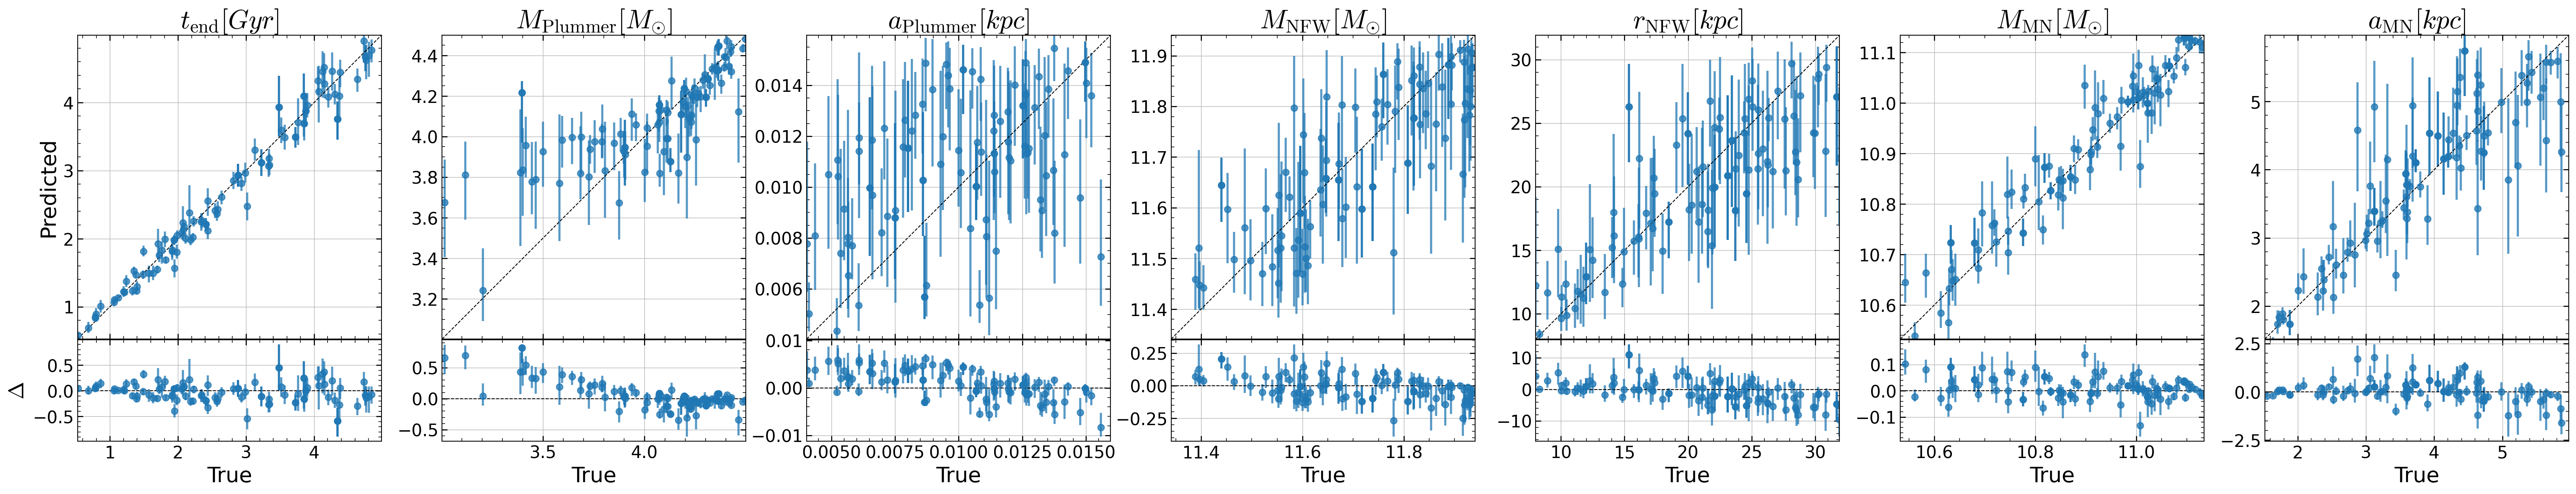

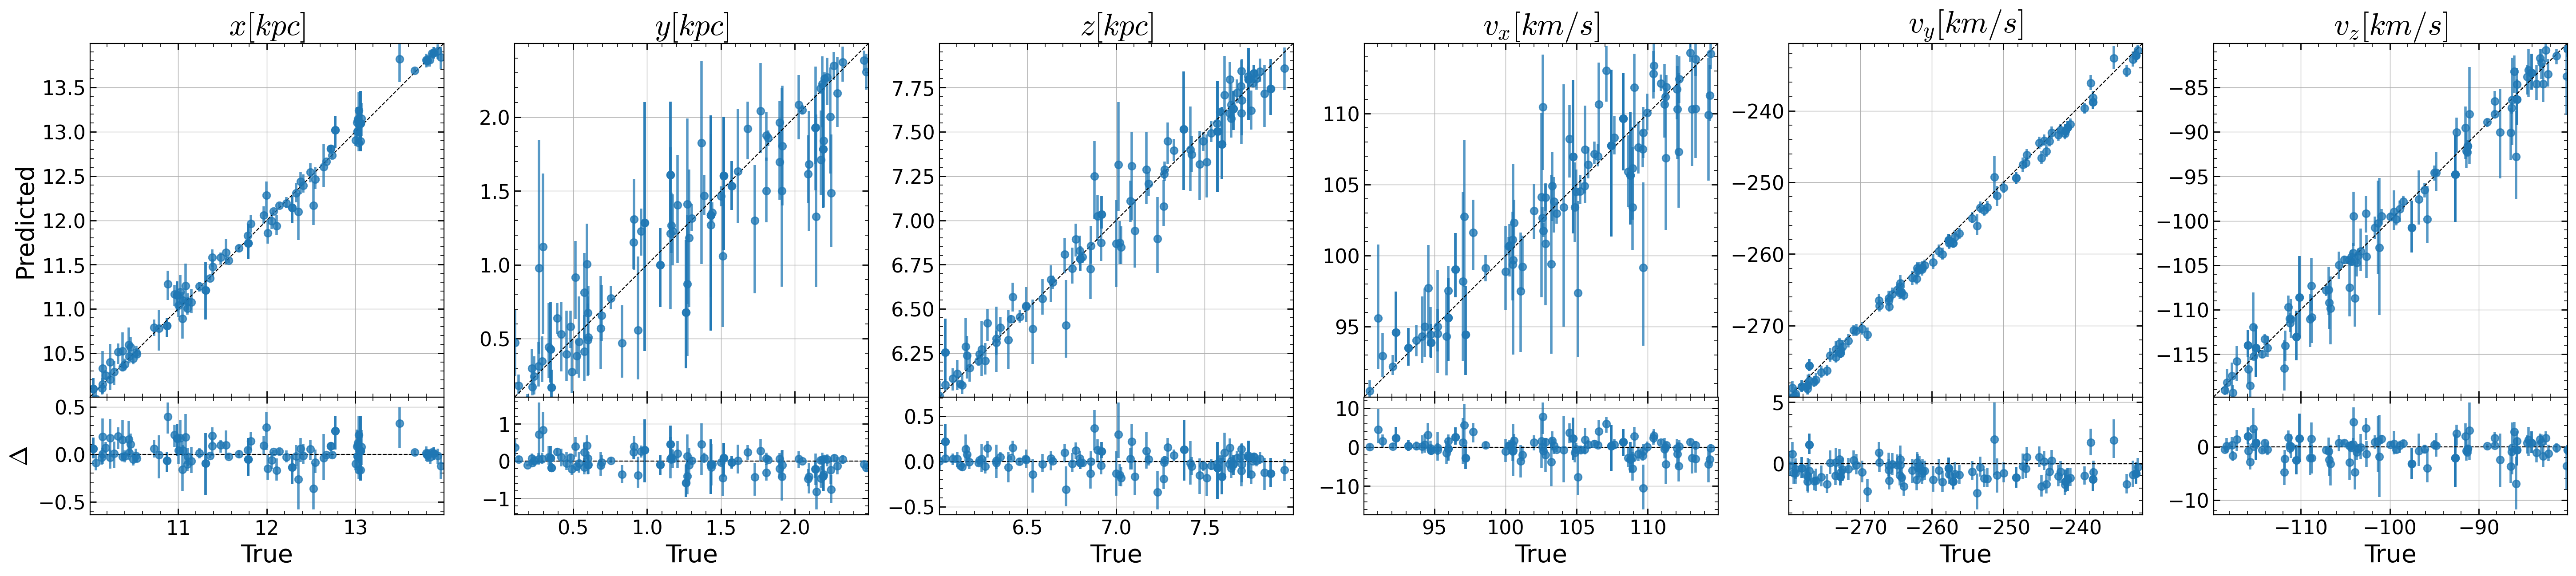

In [5]:
prediction_plot = _plot_predictions(
    samples=predicted_theta,
    trues=true_theta,
    labels=labels
)

# "True" Observation

Parameter $y^c$ in chain Experimental Results is not constrained


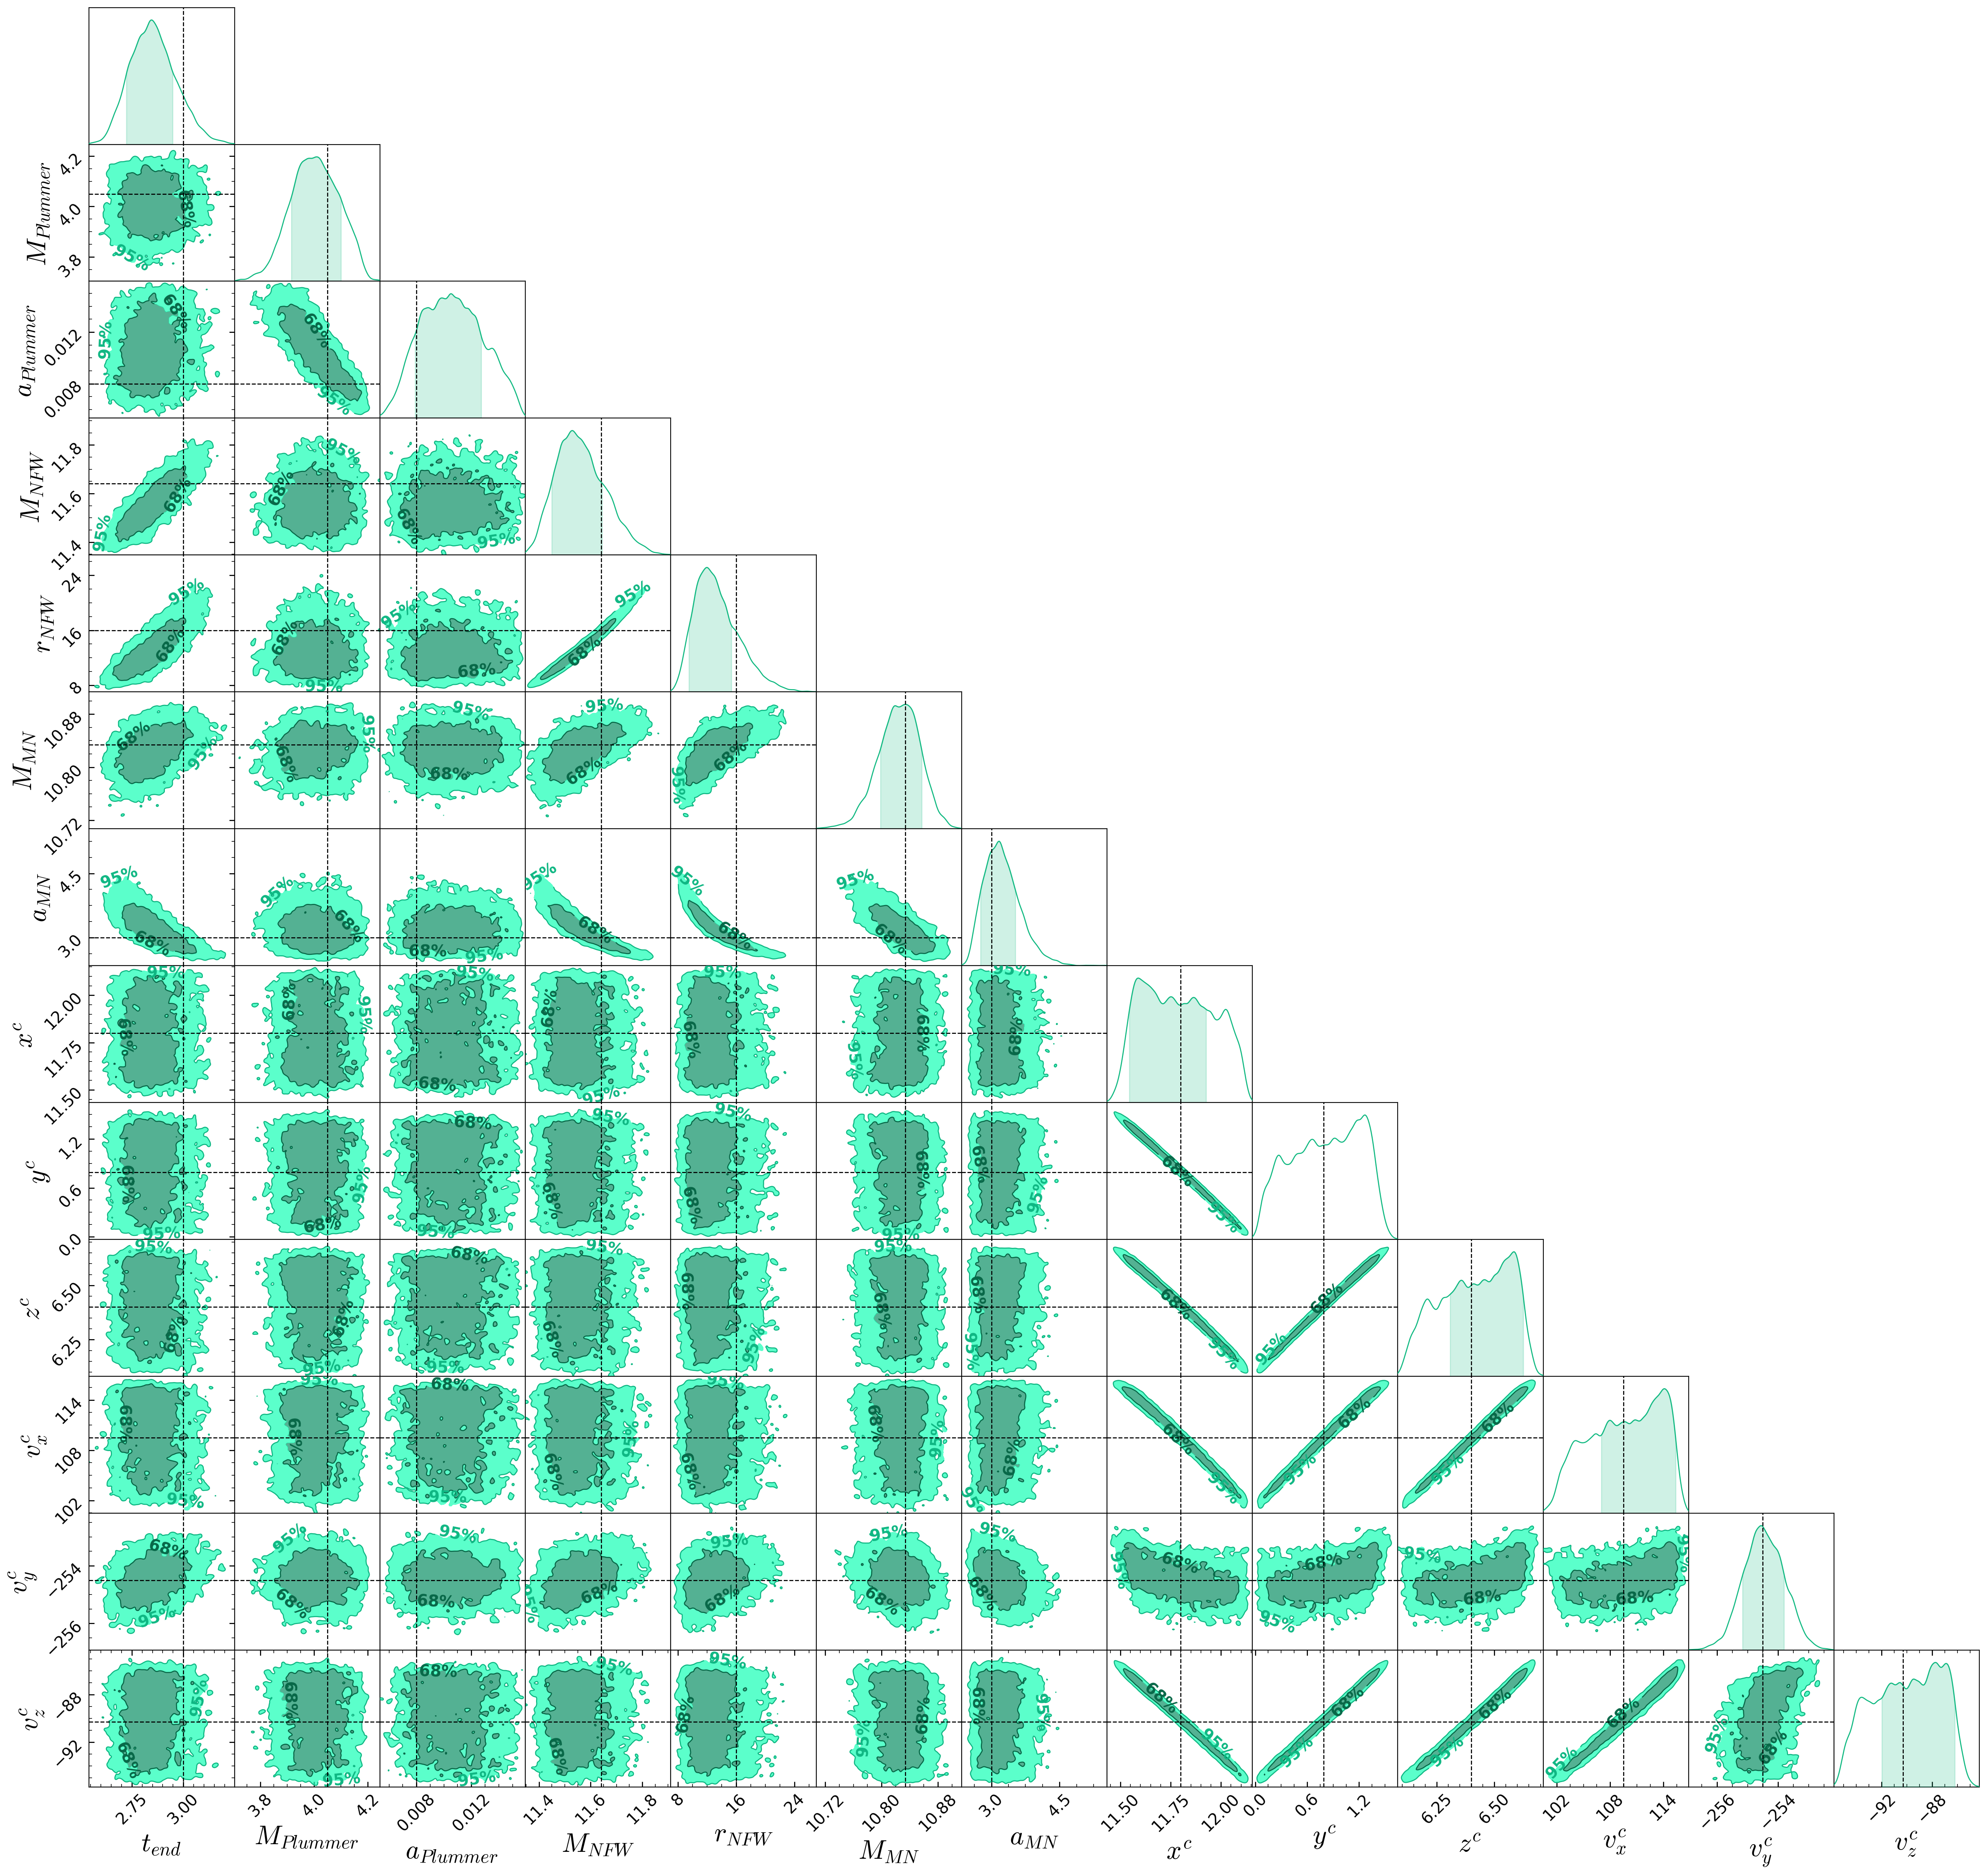

In [6]:
data_true_observation = np.load('../logs/OdisseoCrossAttentionSetTransformer_onehead_2layers_128_AllParameters_Position_uniforprior_2e5_TSIT5_error/pictures/true_observation_prediction.npz')
predicted_theta = data_true_observation['predicted_theta']
true_theta = data_true_observation['true_theta']
labels = ['$t_{end}$', '$M_{Plummer}$', '$a_{Plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$', '$x^c$', '$y^c$', '$z^c$', '$v_x^c$', '$v_y^c$', '$v_z^c$']

df = pd.DataFrame(data=predicted_theta, columns=labels)

c = ChainConsumer()
c.add_chain(Chain(samples=df, 
                  name="Experimental Results", 
                  color="emerald",  
                  show_contour_labels=True,
                  shade_alpha=0.7,
                 )
                 ),

c.add_truth(Truth(location={
             '$t_{end}$': true_theta[0] ,
             '$M_{Plummer}$': np.log10(true_theta[1]),
             '$a_{Plummer}$': true_theta[2],
             '$M_{NFW}$': np.log10(true_theta[3]),
             '$r_{NFW}$': true_theta[4],
             '$M_{MN}$': np.log10(true_theta[5]),
             '$a_{MN}$': true_theta[6],
             '$x^c$': true_theta[7],
             '$y^c$': true_theta[8],
             '$z^c$': true_theta[9],
             '$v_x^c$': true_theta[10],
             '$v_y^c$': true_theta[11],
             '$v_z^c$': true_theta[12]
        }))

c.set_plot_config(
    PlotConfig(
        max_ticks=3,
        label_font_size=25,
        tick_font_size=15,
        summary_font_size=20,
        summarise=False,
        contour_label_font_size=15,
    ))
fig = c.plotter.plot()   

In [8]:
fig.savefig('corner_true_observation.png', bbox_inches='tight', dpi=300)